In [ ]:
!pip install split-folders
!pip install tensorflow
!pip install keras
!pip install matplotlib


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random
import splitfolders
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img
from keras.applications import MobileNetV3Large
from keras.applications.mobilenet_v3 import preprocess_input # Import preprocess_input
from keras import layers, models
from keras.layers import Dense,GlobalAveragePooling2D,Dropout
from keras.models import Sequential
from keras.optimizers import Adam
import seaborn as sns
from sklearn.metrics import confusion_matrix
from keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from keras.utils import load_img, img_to_array

import warnings
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d emmarex/plantdisease


Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 96% 634M/658M [00:01<00:00, 294MB/s]
100% 658M/658M [00:03<00:00, 182MB/s]


In [ ]:
!unzip plantdisease.zip -d plant_disease_data


Streaming output truncated to the last 5000 lines.
  inflating: plant_disease_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plant_disease_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plant_disease_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plant_disease_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plant_disease_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plant_disease_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 0

In [ ]:
IMAGES_FOLDERS_PATH = '/content/plant_disease_data/PlantVillage'
OUTPUT_FOLDER = 'plantdisease_split'
BATCH_SIZE = 32
WIDTH = 224
HEIGHT = 224
CHANNELS = 3
EPOCHS = 35

Classes Number: 15


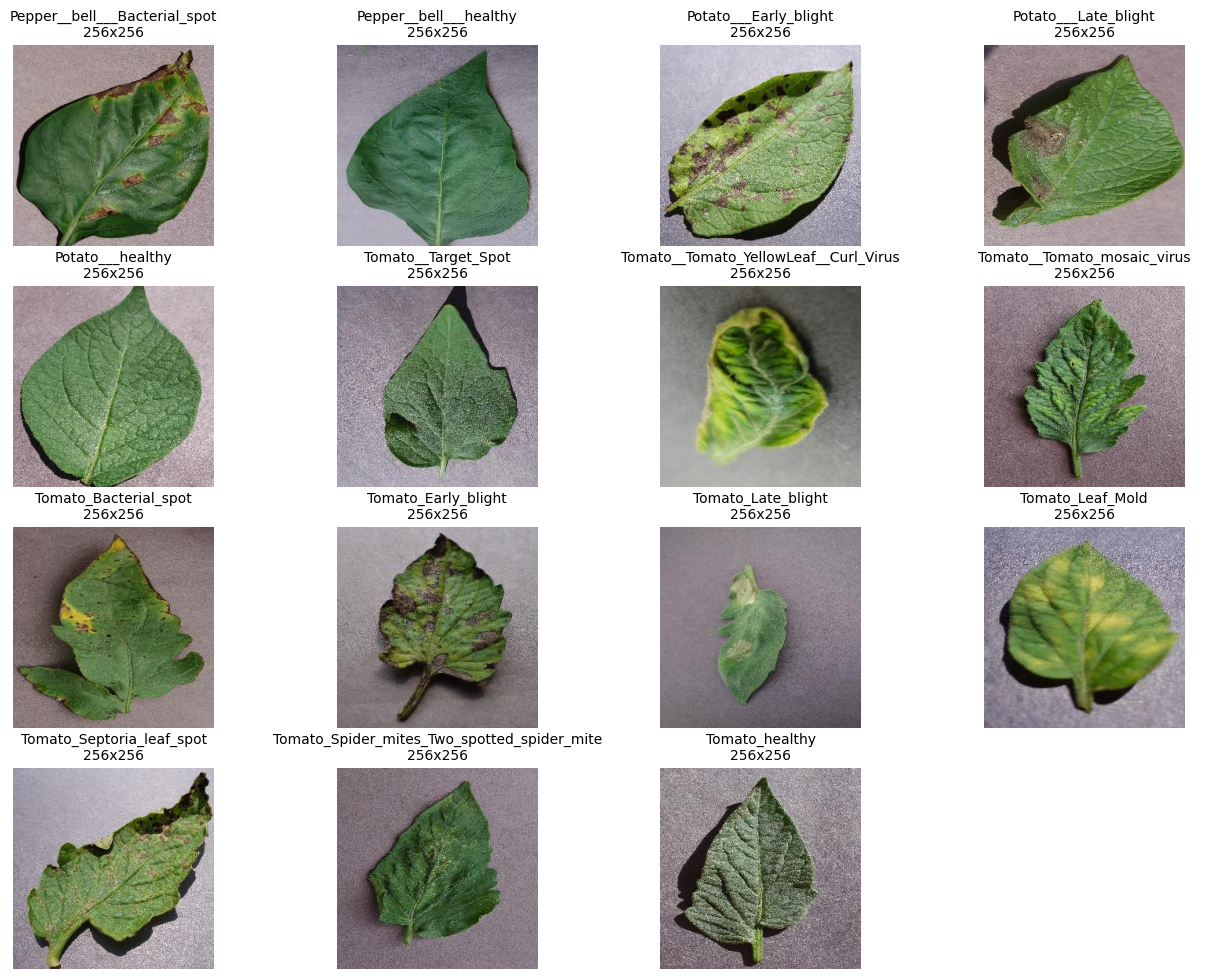

In [ ]:
def VisualizeClasses(folders_path):
    # Get all class folders and sort them
    ClassesNames = os.listdir(folders_path)
    ClassesNames.sort(key=lambda x: (x.split('__')[0], x))

    # Display the total number of classes
    NUM_CLASSES = len(ClassesNames)
    print(f"Classes Number: {NUM_CLASSES}")

    # Prepare the grid for showing sample images
    cols = 4
    rows = (NUM_CLASSES + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
    axes = axes.flatten()

    # Show one sample image from each class
    for i, cat in enumerate(ClassesNames):
        ClassFolderPath = os.path.join(folders_path,cat)
        ImagesName = os.listdir(ClassFolderPath)
        img_path = os.path.join(ClassFolderPath,ImagesName[0])
        with Image.open(img_path) as img:
            width, height = img.size
        image = mpimg.imread(img_path)
        axes[i].imshow(image)
        axes[i].set_title(f"{cat}\n{width}x{height}", fontsize=10)
        axes[i].axis('off')

    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

# Call the function to visualize all classes
VisualizeClasses(IMAGES_FOLDERS_PATH)


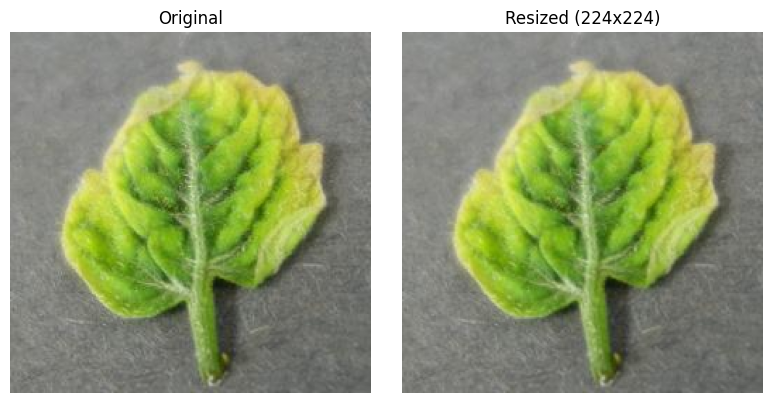

In [ ]:
# Pick a random class folder
ClassesNames = os.listdir(IMAGES_FOLDERS_PATH)
random_class = random.choice(ClassesNames)
class_path = os.path.join(IMAGES_FOLDERS_PATH, random_class)

# Pick a random image from that class
images = os.listdir(class_path)
random_image = random.choice(images)
img_path = os.path.join(class_path, random_image)

# Open and resize the selected image to 224x224
with Image.open(img_path) as img:
    resized_img = img.resize((WIDTH, HEIGHT))

# Display the original and resized images side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mpimg.imread(img_path))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(resized_img)
axes[1].set_title(f"Resized ({WIDTH}x{HEIGHT})")
axes[1].axis('off')

# Adjust layout and show the figure
plt.tight_layout()
plt.show()

In [ ]:
# Split the dataset into training (80%) and validation (20%) folders
splitfolders.ratio(IMAGES_FOLDERS_PATH, output=OUTPUT_FOLDER, seed=42, ratio=(0.8, 0.2))

Copying files: 20639 files [00:04, 4908.72 files/s]


In [ ]:
# Define the training and validation dataset paths
TRAIN_FOLDER_PATH = '/content/plantdisease_split/train'
VAL_FOLDER_PATH = '/content/plantdisease_split/val'



# Data augmentation for training images (adds variations to improve generalization)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Apply MobileNetV3 preprocessing
    rotation_range=20, # Random rotations
    width_shift_range=0.2, # Horizontal shifts
    height_shift_range=0.2, # Vertical shifts
    shear_range=0.2, # Shear transformations
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest' # Fill missing pixels after transformations
)
train_image_generator = train_datagen.flow_from_directory(
                                            TRAIN_FOLDER_PATH,
                                            target_size=(WIDTH, HEIGHT), # Resize all images to 224x224
                                            batch_size= BATCH_SIZE, # Number of images per batch
                                            class_mode='categorical') # Multi-class classification


# Validation images (no augmentation, only preprocessing)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_image_generator = val_datagen.flow_from_directory(
                                            VAL_FOLDER_PATH,
                                            target_size=(WIDTH, HEIGHT),
                                            batch_size= BATCH_SIZE,
                                            class_mode='categorical')

Found 16504 images belonging to 15 classes.
Found 4134 images belonging to 15 classes.


In [ ]:
class_names = list(val_image_generator.class_indices.keys())
class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [ ]:
# Load the MobileNetV3-Large model pre-trained on ImageNet (without the top classification layer)
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(WIDTH, HEIGHT, CHANNELS))

# Freeze the base model layers to keep pretrained weights during initial training
base_model.trainable = False

# Build the new model on top of the base model
model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4207740893457198))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4207740893457198))
model.add(Dense(train_image_generator.num_classes,activation='softmax')) #Output layer for classification

model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137,807 (11.97 MB)

 Trainable params: 141,455 (552.56 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,              # Stop if no improvement for 5 epochs
    restore_best_weights=True # Restore the model weights from the epoch with the best validation loss
)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.00018124783793344046), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
hist = model.fit(
    train_image_generator,
    epochs = EPOCHS,
    verbose = 1,
    callbacks = early_stopping,
    validation_data = val_image_generator
)
# Save the trained model before applying fine-tuning
model.save("mobilenetv3_after_optuna.keras")
files.download("mobilenetv3_after_optuna.keras")

# Get the training history
h_before = hist.history

# Set plotting style
plt.style.use('ggplot')
plt.figure(figsize=(12, 8))
plt.title("Training vs Validation Accuracy and Loss Over Epochs (Before - FineTuning- )")


# Plot training and validation loss
plt.plot(h_before['loss'], c='red', label='Training Loss')
plt.plot(h_before['val_loss'], c='red', linestyle='--', label='Validation Loss')

# Plot training and validation accuracy
plt.plot(h_before['accuracy'], c='blue', label='Training Accuracy')
plt.plot(h_before['val_accuracy'], c='blue', linestyle='--', label='Validation Accuracy')

plt.xlabel("Number of Epochs")
plt.legend(loc='best')
plt.show()

model_before = load_model("mobilenetv3_before_finetuning.keras")
loss, accuracy = model_before.evaluate(val_image_generator, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

val_image_generator.shuffle = False
pred_before = model_before.predict(val_image_generator)

true_labels = val_image_generator.classes

pred_before_classes = np.argmax(pred_before, axis=1)

cm_before = confusion_matrix(true_labels, pred_before_classes)

plt.figure(figsize=(12, 5))

# ---------- FIGURE 1 (Before) ----------
plt.figure(figsize=(6, 5))
sns.heatmap(cm_before, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Before Fine-Tuning")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---- Classification Report ----
report = classification_report(true_labels, pred_before_classes, target_names=class_names)
print("\nClassification Report Before Fine-Tuning :")
print(report)


Epoch 1/35
516/516 ━━━━━━━━━━━━━━━━━━━━ 892s 2s/step - accuracy: 0.2668 - loss: 2.3983 - val_accuracy: 0.7221 - val_loss: 0.9847
Epoch 2/35
516/516 ━━━━━━━━━━━━━━━━━━━━ 961s 2s/step - accuracy: 0.6336 - loss: 1.1504 - val_accuracy: 0.8149 - val_loss: 0.6106
Epoch 3/35
516/516 ━━━━━━━━━━━━━━━━━━━━ 873s 2s/step - accuracy: 0.7403 - loss: 0.7998 - val_accuracy: 0.8636 - val_loss: 0.4404
Epoch 4/35
516/516 ━━━━━━━━━━━━━━━━━━━━ 890s 2s/step - accuracy: 0.7886 - loss: 0.6545 - val_accuracy: 0.8926 - val_loss: 0.3614
Epoch 5/35
516/516 ━━━━━━━━━━━━━━━━━━━━ 866s 2s/step - accuracy: 0.8192 - loss: 0.5511 - val_accuracy: 0.9086 - val_loss: 0.2952
Epoch 6/35
516/516 ━━━━━━━━━━━━━━━━━━━━ 883s 2s/step - accuracy: 0.8436 - loss: 0.4828 - val_accuracy: 0.9211 - val_loss: 0.2605
Epoch 7/35
516/516 ━━━━━━━━━━━━━━━━━━━━ 866s 2s/step - accuracy: 0.8545 - loss: 0.4585 - val_accuracy: 0.9211 - val_loss: 0.2423
Epoch 8/35
516/516 ━━━━━━━━━━━━━━━━━━━━ 885s 2s/step - accuracy: 0.8661 - loss: 0.4132 - val_accu

In [ ]:
# Unfreeze the last 30 layers of the base model to fine-tune higher-level features
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,              # Stop if no improvement for 5 epochs
    restore_best_weights=True # Restore the model weights from the epoch with the best validation loss
)

for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile the model with a smaller learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train (fine-tune) the model again on the training data
fine_tune_history = model.fit(
    train_image_generator,
    validation_data=val_image_generator,
    epochs=EPOCHS,
    callbacks = early_stopping,
    verbose=1
)
model.save("mobilenetv3_after_optuna_finetuning.keras")
import time
time.sleep(5) # Add a small delay after saving
files.download("mobilenetv3_after_optuna_finetuning.keras")

KeyboardInterrupt: 

In [ ]:
model_after = load_model("mobilenetv3_after_finetuning.keras")
loss, accuracy = model_after.evaluate(val_image_generator, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

NameError: name 'load_model' is not defined

In [ ]:
model_before = load_model("/content/mobilenetv3_before_finetuning.keras")
loss, accuracy = model_before.evaluate(val_image_generator, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.9636 - loss: 0.0969
Test Accuracy: 96.44%
Test Loss: 0.0952


In [ ]:
val_image_generator.shuffle = False
pred_before = model_before.predict(val_image_generator)

65/65 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step


In [ ]:
pred_after = model_after.predict(val_image_generator)


65/65 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step


[13  7  5 ...  5  2  5]


<Figure size 1200x500 with 0 Axes>

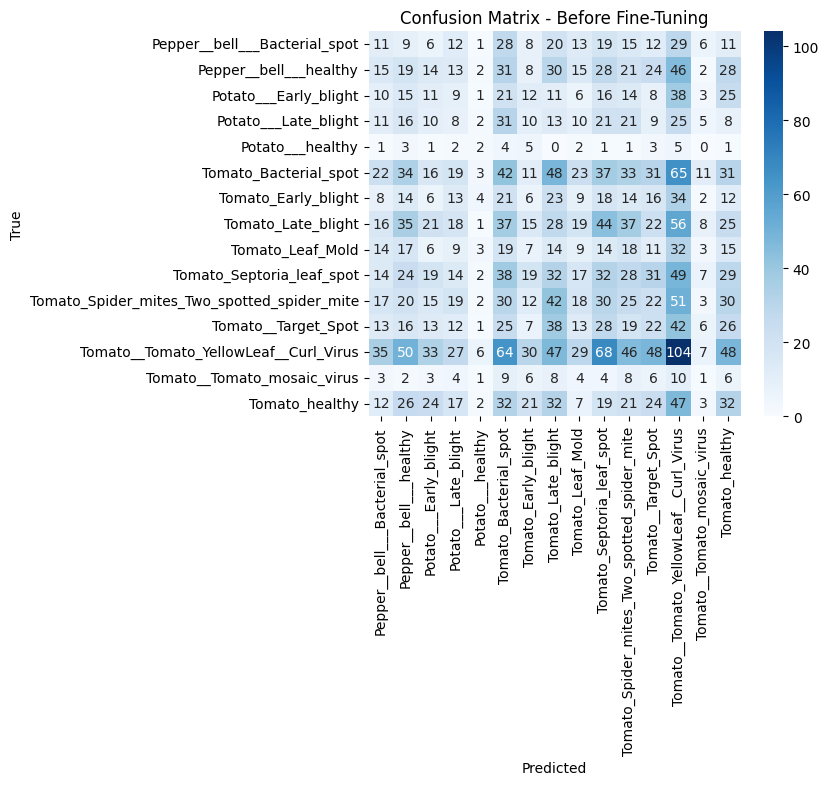

In [ ]:
true_labels = val_image_generator.classes

pred_before_classes = np.argmax(pred_before, axis=1)
print(pred_before_classes)
cm_before = confusion_matrix(true_labels, pred_before_classes)

plt.figure(figsize=(12, 5))

# ---------- FIGURE 1 (Before) ----------
plt.figure(figsize=(6, 5))
sns.heatmap(cm_before, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Before Fine-Tuning")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

<Figure size 1200x500 with 0 Axes>

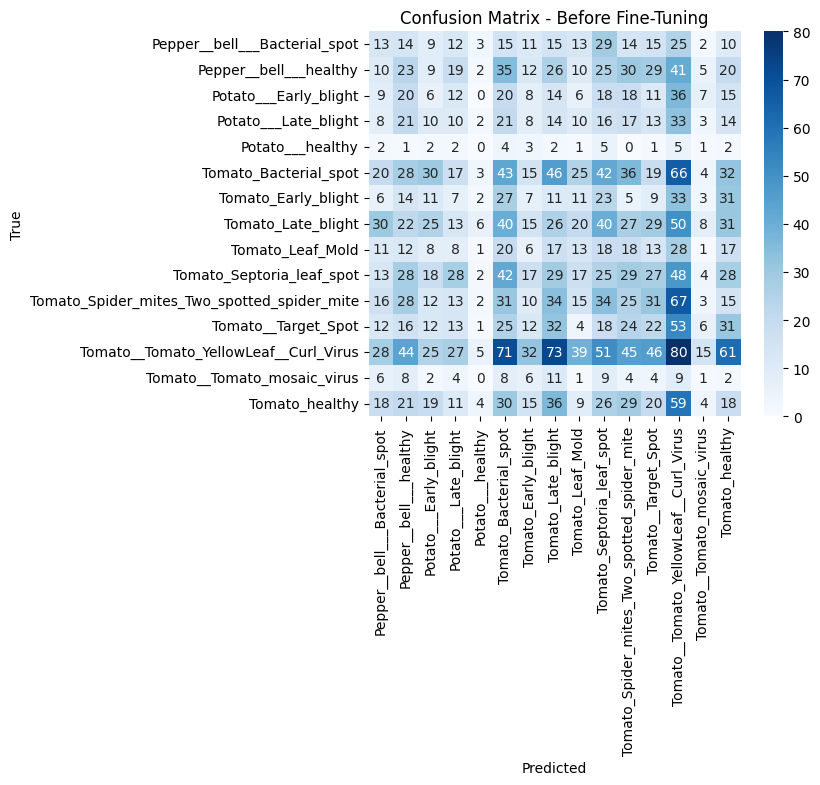

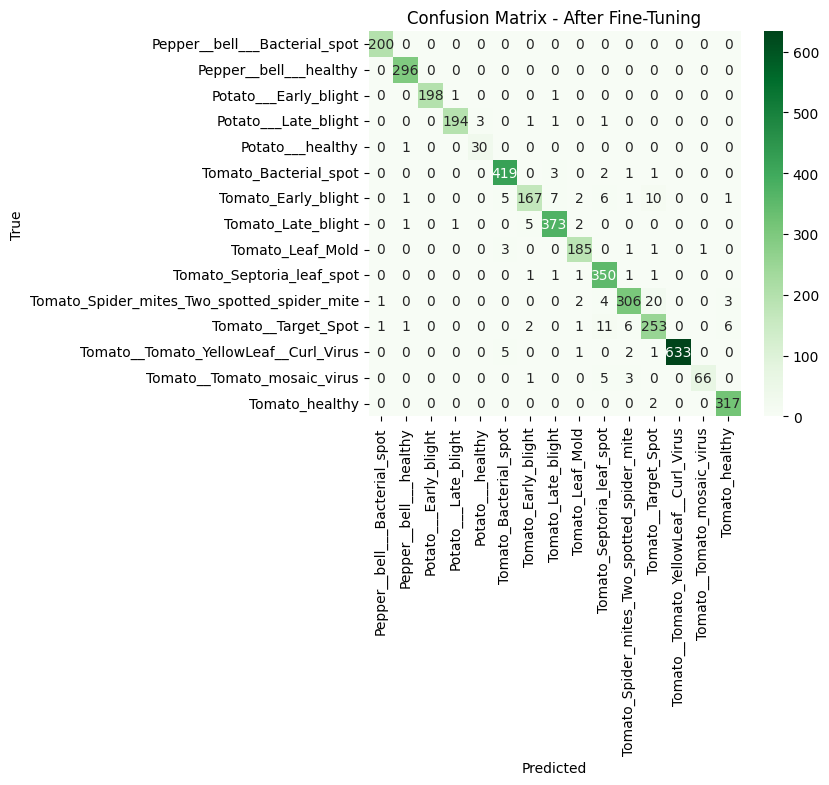

In [ ]:
true_labels = val_image_generator.classes

pred_before_classes = np.argmax(pred_before, axis=1)
pred_after_classes = np.argmax(pred_after, axis=1)

cm_before = confusion_matrix(true_labels, pred_before_classes)
cm_after = confusion_matrix(true_labels, pred_after_classes)

plt.figure(figsize=(12, 5))

# ---------- FIGURE 1 (Before) ----------
plt.figure(figsize=(6, 5))
sns.heatmap(cm_before, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Before Fine-Tuning")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------- FIGURE 2 (After) ----------
plt.figure(figsize=(6, 5))
sns.heatmap(cm_after, annot=True, fmt="d", cmap="Greens",
             xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - After Fine-Tuning")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# ---- Classification Report ----
report = classification_report(true_labels, pred_before_classes, target_names=class_names)
print("\nClassification Report Before Fine-Tuning :")
print(report)


Classification Report Before Fine-Tuning :
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.06      0.07      0.06       200
                     Pepper__bell___healthy       0.08      0.08      0.08       296
                      Potato___Early_blight       0.03      0.03      0.03       200
                       Potato___Late_blight       0.05      0.05      0.05       200
                           Potato___healthy       0.00      0.00      0.00        31
                      Tomato_Bacterial_spot       0.10      0.10      0.10       426
                        Tomato_Early_blight       0.04      0.04      0.04       200
                         Tomato_Late_blight       0.07      0.07      0.07       382
                           Tomato_Leaf_Mold       0.07      0.07      0.07       191
                  Tomato_Septoria_leaf_spot       0.07      0.07      0.07       355
Tomato_Spider_mites_

In [ ]:
# ---- Classification Report ----
report = classification_report(true_labels, pred_after_classes, target_names=class_names)
print("\nClassification Report After Fine-Tuning :")
print(report)


Classification Report After Fine-Tuning :
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      1.00      1.00       200
                     Pepper__bell___healthy       0.99      1.00      0.99       296
                      Potato___Early_blight       1.00      0.99      0.99       200
                       Potato___Late_blight       0.99      0.97      0.98       200
                           Potato___healthy       0.91      0.97      0.94        31
                      Tomato_Bacterial_spot       0.97      0.98      0.98       426
                        Tomato_Early_blight       0.94      0.83      0.89       200
                         Tomato_Late_blight       0.97      0.98      0.97       382
                           Tomato_Leaf_Mold       0.95      0.97      0.96       191
                  Tomato_Septoria_leaf_spot       0.92      0.99      0.95       355
Tomato_Spider_mites_T

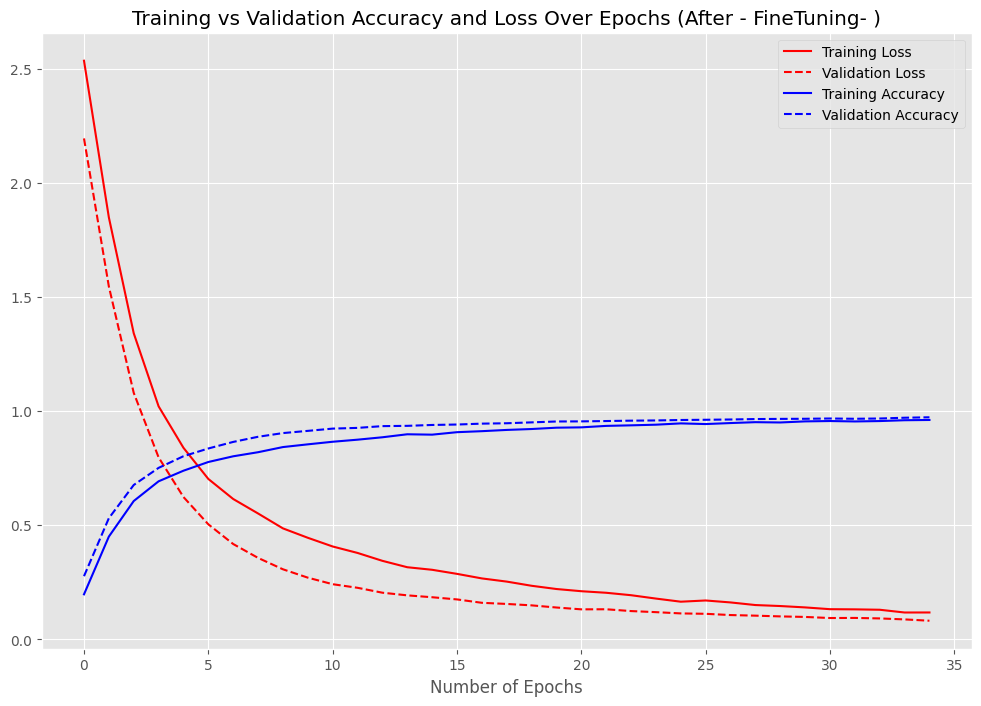

In [ ]:
# Get the training history
h = fine_tune_history.history

# Set plotting style
plt.style.use('ggplot')
plt.figure(figsize=(12, 8))
plt.title("Training vs Validation Accuracy and Loss Over Epochs (After - FineTuning- )")


# Plot training and validation loss
plt.plot(h['loss'], c='red', label='Training Loss')
plt.plot(h['val_loss'], c='red', linestyle='--', label='Validation Loss')

# Plot training and validation accuracy
plt.plot(h['accuracy'], c='blue', label='Training Accuracy')
plt.plot(h['val_accuracy'], c='blue', linestyle='--', label='Validation Accuracy')

plt.xlabel("Number of Epochs")
plt.legend(loc='best')
plt.show()

In [ ]:
def PredictImageFromPath(image_path,actual):

     # Load and preprocess the image
    img = load_img(image_path, target_size=(WIDTH,HEIGHT))
    img_array = preprocess_input(img_to_array(img))
    img_array_exp = np.expand_dims(img_array, axis=0) # Add batch dimension

    # Make prediction
    pred = model_after.predict(img_array_exp, verbose=0)
    class_index = np.argmax(pred, axis=1)[0]
    label = class_names[class_index]

    # Display the image with predicted label
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicted: {label} \n Actual: {actual}")
    plt.axis('off')
    plt.show()

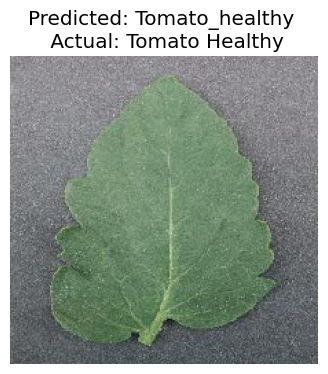

In [ ]:
PredictImageFromPath("/content/plantdisease_split/val/Tomato_healthy/063d05a7-1a53-4631-818d-44b34126974e___GH_HL Leaf 453.JPG","Tomato Healthy")

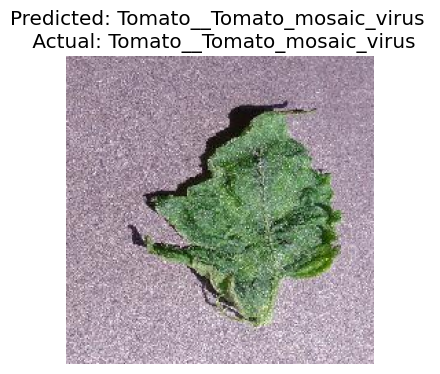

In [ ]:
PredictImageFromPath("/content/plantdisease_split/val/Tomato__Tomato_mosaic_virus/01b32f27-2b9b-4961-805b-8066bf4d90f1___PSU_CG 2417.JPG","Tomato__Tomato_mosaic_virus")

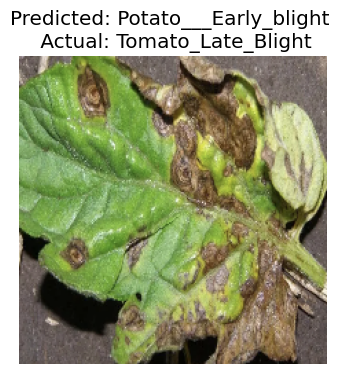

In [ ]:
PredictImageFromPath("/content/Test_Images/Tomato_Late_Blight.png","Tomato_Late_Blight")

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow import keras
from google.colab import files

# -----------------------------
# 1. Use the model object from the previous cell
# -----------------------------
# The 'model' object already contains the fine-tuned model from the previous cell.
# No need to load it from the file here.

# -----------------------------
# 2. Rebuild the base model and prepare for fine-tuning (already done in previous cell)
# -----------------------------
# The base model layers are already unfrozen in the previous cell.

# -----------------------------
# 3. Apply best hyperparameters from Optuna
# -----------------------------
dense_units_1 = 768
dense_units_2 = 256
dropout_rate = 0.2655779240737327
learning_rate = 0.00028495190396044727
optimizer_choice = "RMSprop"

# Select the optimizer
if optimizer_choice == "RMSprop":
    optimizer = RMSprop(learning_rate=learning_rate)
else:
    optimizer = Adam(learning_rate=learning_rate)

# Recompile with the new optimizer and learning rate
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# 4. Define early stopping (already defined in previous cell)
# -----------------------------
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# 5. Fine-tune the model
# -----------------------------
# Reduce epochs for demonstration; adjust as needed
EPOCHS = 25

fine_tune_history = model.fit(
    train_image_generator,
    validation_data=val_image_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

# -----------------------------
# 6. Save and download fine-tuned model
# -----------------------------
model.save("/content/mobilenetv3_after_finetuning_with_optuna.keras")
files.download("/content/mobilenetv3_after_finetuning_with_optuna.keras")

print("✅ Fine-tuning completed and model saved as mobilenetv3_after_finetuning_with_optuna.keras")

Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 623s 2s/step - accuracy: 0.6681 - loss: 1.0733 - val_accuracy: 0.6708 - val_loss: 1.0545
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 626s 2s/step - accuracy: 0.9331 - loss: 0.2036 - val_accuracy: 0.7939 - val_loss: 0.7945
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 627s 2s/step - accuracy: 0.9571 - loss: 0.1295 - val_accuracy: 0.9250 - val_loss: 0.2747
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 675s 3s/step - accuracy: 0.9704 - loss: 0.0902 - val_accuracy: 0.9441 - val_loss: 0.2757
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 622s 2s/step - accuracy: 0.9814 - loss: 0.0621 - val_accuracy: 0.9429 - val_loss: 0.3041
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 645s 3s/step - accuracy: 0.9833 - loss: 0.0498 - val_accuracy: 0.9649 - val_loss: 0.2036
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 628s 2s/step - accuracy: 0.9849 - loss: 0.0454 - val_accuracy: 0.9640 - val_loss: 0.2183
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 633s 2s/step - accuracy: 0.9872 - loss: 0.0409 - val_accu

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Fine-tuning completed and model saved as mobilenetv3_after_finetuning_with_optuna.keras
